# 08 · Robotics: depth, grasps and the support surface

A robot arm that picks objects must answer three questions: *where are the objects?*, *which
one is nearest?* and *where can my gripper hold it?* VisionServe has models for each step. In
this notebook you use them on two photos (a lunch box and a desk) and learn what they can and
cannot tell you.

**What you will learn**

- read a **depth map** and find the nearest object
- plan **grasps** for a two-finger gripper with `grasp-rfdetr`, and read each grasp's fields
- limit the grasps to your gripper with `gripper_min` / `gripper_max`
- find the **support surface** (the table) with the `background` model, `method="sam"` vs `"auto"`
- the **limits**: relative depth, analytic grasp quality

**Time needed:** about 40 minutes.

**What you need before you start**

- notebooks [00](00-overview-and-quickstart.ipynb) and [01](01-tour-of-tasks.ipynb) (masks, depth)
- a running server; models `midas`, `grasp-rfdetr` and `background` (downloaded the first time)
- no robot: everything works on photos

**Steps**

1. Depth: near and far
2. Which object is nearest?
3. Grasps: where a gripper can hold an object
4. `gripper_min` and `gripper_max`: fit your gripper
5. How many grasps per object
6. The support surface: `background`
7. Put it together: pick the nearest object
8. Limits: what these numbers do **not** tell you

## Setup

In [1]:
import numpy as np
from PIL import Image
from handson import connect, ensure_model, photo, show, show_side_by_side, draw, table

client = connect()
for name in ["midas", "grasp-rfdetr", "background"]:
    ensure_model(client, name)

Connected to VisionServe at http://127.0.0.1:11435: {'status': 'ok'}
Model 'midas' is installed (state: loaded).
Model 'grasp-rfdetr' is installed (state: loaded).
Model 'background' is installed (state: loaded).


**What you see**

One line for the connection and one line per model.

<details><summary><b>In detail</b></summary>

`grasp-rfdetr` uses RF-DETR (to find objects) and MobileSAM (to outline them) inside;
`background` uses MobileSAM and MiDaS. `visionserve pull` downloads the parts they need. See
[Pipelines](https://mtbui2010.github.io/vision_serve/architecture/pipelines/).

</details>

## 1. Depth: near and far

`midas` estimates depth from **one** normal photo. Its answer is a **depth map**: one number
per pixel (at the model's own size, 256 x 256). **Larger means nearer.**

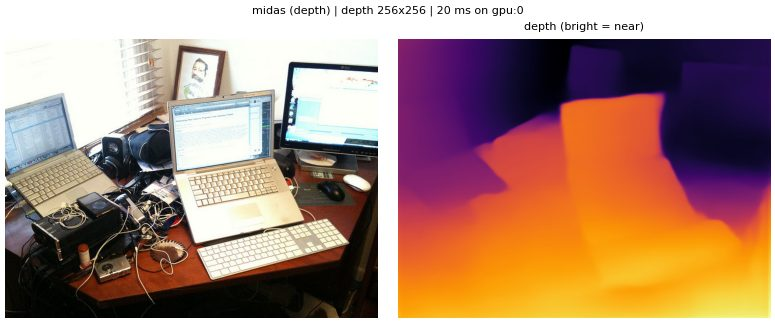

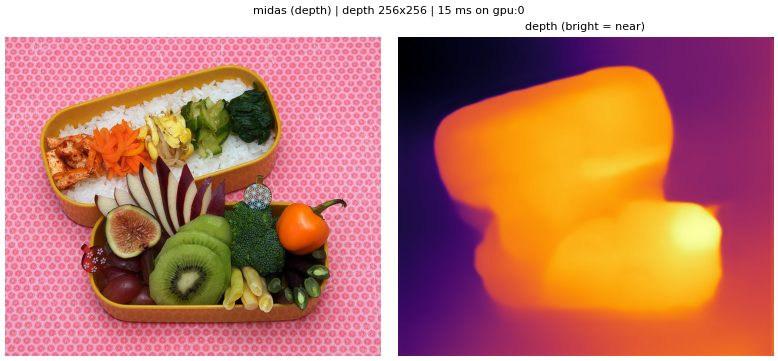

In [2]:
depth_res = {}
for key in ["desk", "food"]:
    depth_res[key] = client.predict("midas", photo(key))
    show(photo(key), depth_res[key], max_width=800)

**What you see**

Two rows: the photo on the left, the depth map on the right (**bright = near, dark = far**).

- Desk: the keyboard and the front edge of the desk are bright; the monitor and the wall at the
  back are dark.
- Lunch box: the boxes are brighter (nearer) than the pink cloth. The real difference is only
  a few centimeters, but the map always uses the full range from dark to bright (section 8
  explains why this matters).

<details><summary><b>In detail</b></summary>

- The numbers are **relative inverse depth** (they grow when the distance gets smaller, like
  1 / distance), scaled to 0..1 for each photo. Section 8 explains
  what this means for a robot.
- `depth-anything-v2` is more accurate and slower. See [Depth](https://mtbui2010.github.io/vision_serve/concepts/tasks/#depth-how-far-is-each-pixel).

</details>

## 2. Which object is nearest?

Now we combine two answers: the **objects** (with their masks, from `grasp-rfdetr`) and the
**depth map**. For each object we take the **median** depth value of its mask pixels (the middle
value; it is not disturbed by a few wrong pixels). The largest value is the nearest object.

The depth map is 256 x 256, so first we resize it to the photo's size.

In [3]:
def depth_at_photo_size(res, width, height):
    """The depth map as a numpy array with the photo's size (height, width)."""
    small = Image.fromarray(res.depth_array())
    return np.asarray(small.resize((width, height), Image.BILINEAR))

key = "desk"
w, h = Image.open(photo(key)).size
depth = depth_at_photo_size(depth_res[key], w, h)
objects = client.predict("grasp-rfdetr", photo(key))

rows = []
for det, mask in zip(objects.detections, objects.masks):
    pixels = mask.to_ndarray(w, h)                 # True on the object
    rows.append([det.cls, round(det.conf, 2), round(float(np.median(depth[pixels])), 3)])
rows.sort(key=lambda r: -r[2])                     # nearest first
table(rows, ["object", "conf", "depth (larger = nearer)"])

object,conf,depth (larger = nearer)
keyboard,0.94,0.798
laptop,0.97,0.664
laptop,0.93,0.343
mouse,0.94,0.304
mouse,0.87,0.244
tv,0.89,0.101


**What you see**

A table with one row per object, the nearest first. The keyboard and the laptop in front are
nearest; the monitor ("tv") at the back is the farthest.

<details><summary><b>In detail</b></summary>

- We use the **mask**, not the box: a box also contains background pixels, which would mix
  near and far values.
- `grasp-rfdetr` returns one mask per detection, in the same order, so `zip` pairs them.
- The SDK has helpers for this with a real depth camera: `object_distances`,
  `select_target_object`. They refuse `midas` depth when you ask for meters. See
  [Helpers](https://mtbui2010.github.io/vision_serve/clients/python/#helpers) and the recipe [Grasp with a depth camera](https://mtbui2010.github.io/vision_serve/clients/python/#grasp-with-a-depth-camera).

</details>

## 3. Grasps: where a gripper can hold an object

A **two-finger gripper** (also called a *parallel-jaw* gripper) holds an object between two
flat **jaws** that close toward each other. A **grasp** says where to put the gripper.

`grasp-rfdetr` finds the objects (RF-DETR), outlines them (MobileSAM), and then **computes**
good grasps from each outline. Each grasp has these fields:

| Field | Meaning |
|---|---|
| `x`, `y` | the center of the grasp, in photo pixels |
| `theta` | the direction in which the jaws close, an angle in **radians** (3.14 radians = 180 degrees; 0 = left-right, about 1.57 = up-down) |
| `width` | how far the jaws must open, in photo pixels |
| `quality` | a score from 0 to 1: how good the grasp looks |
| `cls`, `conf` | the object's class and its detection score |

In the picture, each grasp is a line between the two jaw positions, with a short bar for each
jaw. Green = high quality, red = low quality.

objects: ['broccoli', 'carrot', 'bowl'] | grasps: 9


object,x,y,theta (rad),width (px),quality
broccoli,424,332,3.02,76.5,0.966
broccoli,424,331,3.06,76.2,0.966
broccoli,424,330,3.08,77.2,0.965
bowl,252,220,2.36,12.7,0.99
bowl,251,221,2.36,14.1,0.99
bowl,251,220,2.3,12,0.99
bowl,274,228,0.46,11.2,0.993
bowl,276,232,0.79,21.2,0.991
bowl,276,232,0.86,19.8,0.99


pose [x, y, width, theta]: [424.0, 332.5, 76.53, 3.02]
jaw contact points: [[462, 328], [386, 337]]


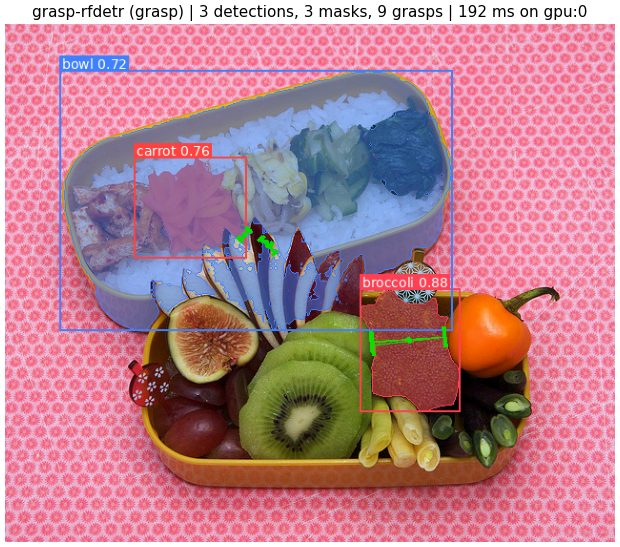

In [4]:
grasps = client.predict("grasp-rfdetr", photo("food"))
print("objects:", [d.cls for d in grasps.detections], "| grasps:", len(grasps.grasps))

table([[g.cls, round(g.x), round(g.y), round(g.theta, 2), round(g.width, 1), round(g.quality, 3)]
       for g in grasps.grasps],
      ["object", "x", "y", "theta (rad)", "width (px)", "quality"])

g = grasps.grasps[0]
print("pose [x, y, width, theta]:", [round(v, 2) for v in g.pose])
print("jaw contact points:", [[round(v) for v in p] for p in g.contacts()])
show(photo("food"), grasps, max_width=700)

**What you see**

- Three objects (broccoli, carrot, bowl) and 9 grasps: the client keeps the best 3 grasps for
  each object (section 5). Three are labelled "broccoli" and six "bowl": the carrot lies inside
  the bowl, and some bowl grasps took the carrot's places (section 5 explains this).
- The broccoli grasps are about 76 pixels wide and close almost left-right (`theta` near 3.1
  radians, that is 180 degrees: the same line as 0).
- Some "bowl" grasps are very narrow (about 12 to 20 pixels): they hold a thin part of the
  outline. This is why you limit the width to your gripper (next section).
- `pose` and `contacts()` give the same grasp in two other forms: one list, or the two points
  where the jaws touch the object.

<details><summary><b>In detail</b></summary>

- The grasps are **computed from the 2-D outline** (an analytic method), not learned from robot
  experience. The model does not know the weight, the material or the 3-D shape.
- The class-agnostic model `grasp` works without names (any object), and `grasp-gd` takes text
  words like GroundingDINO. See [Robot grasping and background](https://mtbui2010.github.io/vision_serve/concepts/tasks/#robot-grasping-and-background).
- All fields: [The Result object](https://mtbui2010.github.io/vision_serve/clients/python/#the-result-object).

</details>

## 4. `gripper_min` and `gripper_max`: fit your gripper

Your gripper can only open between a minimum and a maximum width. Tell the model, **in photo
pixels**:

- `gripper_min`: the smallest opening to propose (default 10 pixels)
- `gripper_max`: the largest opening (default 150 pixels)

Grasps outside this range are never proposed.

default      widths: [11, 12, 13, 14, 20, 21, 76, 77, 77]
40 .. 80 px  widths: [40, 41, 41, 44, 46, 48, 75, 76, 77]


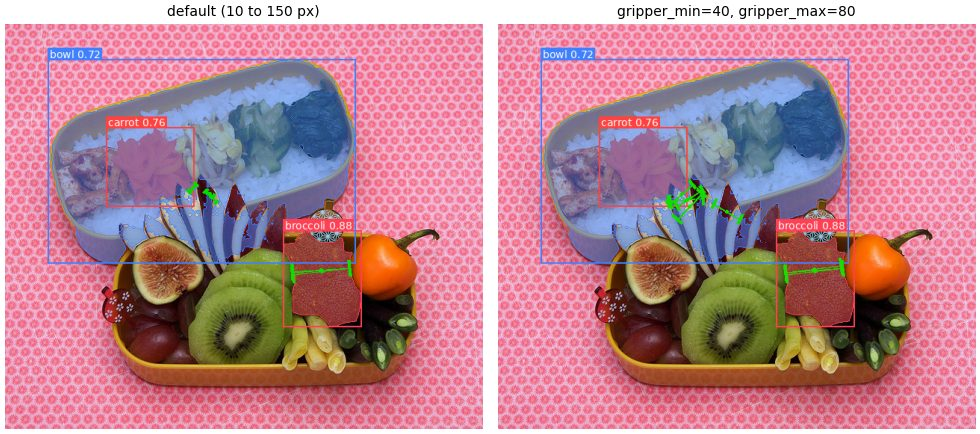

In [5]:
narrow = client.predict("grasp-rfdetr", photo("food"))                                # 10 .. 150
limited = client.predict("grasp-rfdetr", photo("food"), gripper_min=40, gripper_max=80)
for name, res in [("default", narrow), ("40 .. 80 px", limited)]:
    widths = sorted(round(g.width) for g in res.grasps)
    print(f"{name:12s} widths: {widths}")
show_side_by_side([(photo("food"), narrow), (photo("food"), limited)],
                  titles=["default (10 to 150 px)", "gripper_min=40, gripper_max=80"])

**What you see**

- Default: some bowl grasps are only 11 to 21 pixels wide.
- With 40 to 80: every width is between 40 and 80. The bowl grasps moved to places where the
  outline is about 40 pixels across. The broccoli grasps (about 76 pixels) are still allowed.

<details><summary><b>In detail</b></summary>

- To turn your gripper's opening in **millimeters** into pixels you need the camera:
  `pixels = millimeters x fx / Z`, where `fx` is the camera's focal length in pixels and `Z` is
  the distance to the object in millimeters (from a depth camera).
- Read more: [`gripper_min` and `gripper_max`](https://mtbui2010.github.io/vision_serve/clients/python/#gripper_min-and-gripper_max).

</details>

## 5. How many grasps per object

The server returns up to 20 grasps for each object. The Python client then keeps only the best
`max_grasps_per_object` grasps per object (default **3**). This option is not sent to the
server; the client filters the answer.

In [6]:
for n in [1, 3, None]:                          # None = everything the server sent
    res = client.predict("grasp-rfdetr", photo("food"), max_grasps_per_object=n)
    print(f"max_grasps_per_object={n}: {len(res.grasps)} grasps")

max_grasps_per_object=1: 3 grasps


max_grasps_per_object=3: 9 grasps
max_grasps_per_object=None: 60 grasps


**What you see**

1 per object gives 3 grasps, the default gives 9, and `None` gives all of them (60 here, 20 per
object).

<details><summary><b>In detail</b></summary>

- The client groups each grasp with the **smallest** box that contains its center, and keeps
  the best ones of each group. Here the carrot's box is inside the bowl's box, so bowl grasps
  with a center on the carrot are in the carrot's group, and they can win over the carrot's own
  grasps. That is why section 3 shows six "bowl" grasps and no "carrot" grasp. Read more: [`max_grasps_per_object`](https://mtbui2010.github.io/vision_serve/clients/python/#max_grasps_per_object).
- `res.filter_grasps(n)` does the same filtering on a result you already have.

</details>

## 6. The support surface: `background`

A robot also needs to know the **support surface**: the table or floor that the objects stand
on. Everything that is not support surface can be treated as an object. The `background` model
returns **one mask**: the support surface. It has several methods:

- `method="sam"`: MobileSAM, prompted at six points in the lower part of the photo.
- `method="auto"` (default): it uses depth to find a flat plane; if that fails it uses classic
  image processing (no neural network).

The answer can have **no mask at all** when the method finds no surface. Always check
`if res.masks:`.

food  method=sam   53 % of the photo, 491 ms
food  method=auto  no mask found, 108 ms


desk  method=sam   22 % of the photo, 334 ms
desk  method=auto  16 % of the photo, 87 ms


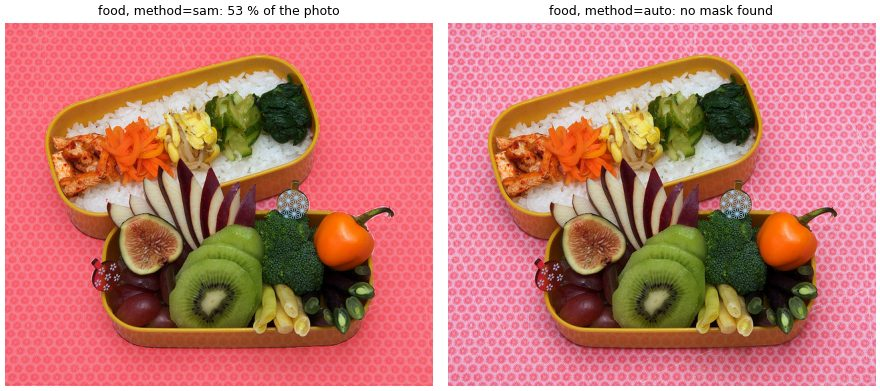

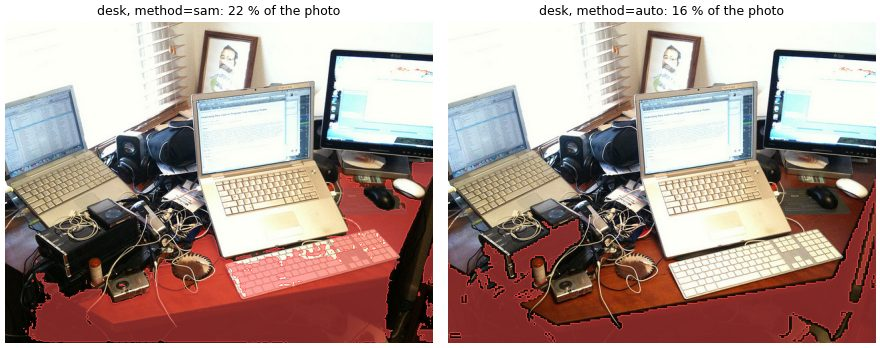

In [7]:
pictures, titles = [], []
for key in ["food", "desk"]:
    w, h = Image.open(photo(key)).size
    for method in ["sam", "auto"]:
        res = client.predict("background", photo(key), method=method)
        if res.masks:
            share = 100 * res.masks[0].to_ndarray(w, h).mean()
            note = f"{share:.0f} % of the photo"
        else:
            note = "no mask found"
        print(f"{key:5s} method={method:5s} {note}, {res.duration_ms:.0f} ms")
        pictures.append((photo(key), res))
        titles.append(f"{key}, method={method}: {note}")
show_side_by_side(pictures[:2], titles[:2], max_width=900)
show_side_by_side(pictures[2:], titles[2:], max_width=900)

**What you see**

- Lunch box: `"sam"` finds the pink cloth (about half of the photo). `"auto"` finds **no
  mask**: the photo is taken from above, so depth shows no clear plane, and the cloth's pattern
  confuses the classic method.
- Desk: both methods find a part of the desk top. `"sam"` takes more time (it runs a neural
  network several times); `"auto"` is faster here.
- The colored area is the surface; the rest (laptops, keyboard, food...) is "not surface".

<details><summary><b>In detail</b></summary>

- Other methods: `"depth"` (depth only), `"cv"` (classic only, very fast), `"automask"`
  (MobileSAM everywhere, keep large regions). `bg_max_area` and `fg_min_area` tune the SAM
  methods. With a depth camera, pass your own depth image with `depth=`.
- Do not use `max_size` with `background`: the surface is large and would be dropped.
- Read more: [`method`](https://mtbui2010.github.io/vision_serve/clients/python/#method) and [`depth`](https://mtbui2010.github.io/vision_serve/clients/python/#depth-an-aligned-depth-image).

</details>

## 7. Put it together: pick the nearest object

A simple plan for a robot: take the **nearest** object, then its **best** grasp (highest
quality) that fits the gripper. We use the desk photo, the depth from section 1 and a gripper
that opens 20 to 120 pixels.

nearest object: keyboard (depth value 0.80)
best grasp: center=(455, 356) width=55 px theta=1.31 rad quality=0.973


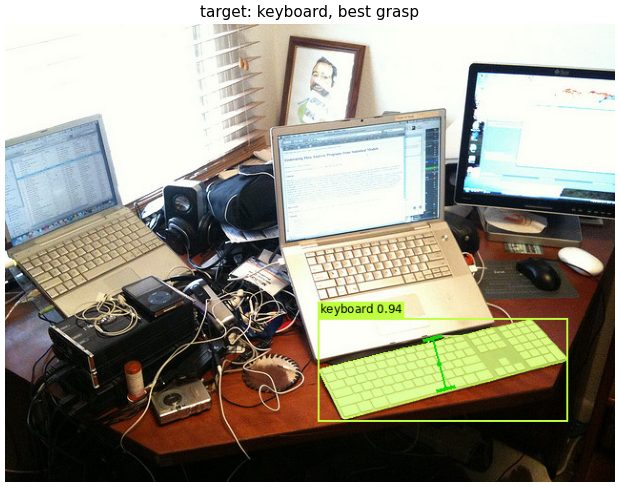

In [8]:
key = "desk"
w, h = Image.open(photo(key)).size
depth = depth_at_photo_size(depth_res[key], w, h)
res = client.predict("grasp-rfdetr", photo(key), gripper_min=20, gripper_max=120)

nearness = [float(np.median(depth[m.to_ndarray(w, h)])) for m in res.masks]
target = int(np.argmax(nearness))                       # index of the nearest object
target_cls = res.detections[target].cls
tx, ty, tw, th = res.detections[target].bbox
in_box = [g for g in res.grasps if tx <= g.x <= tx + tw and ty <= g.y <= ty + th]
in_box = in_box or [g for g in res.grasps if g.cls == target_cls]   # (a fallback; rarely needed)
best = max(in_box, key=lambda g: g.quality)
print(f"nearest object: {target_cls} (depth value {nearness[target]:.2f})")
print(f"best grasp: center=({best.x:.0f}, {best.y:.0f}) width={best.width:.0f} px "
      f"theta={best.theta:.2f} rad quality={best.quality:.3f}")

from visionserve import Result
plan = Result(task="grasp", model="plan", detections=[res.detections[target]],
              masks=[res.masks[target]], grasps=[best])
show(photo(key), plan, title=f"target: {target_cls}, best grasp", max_width=700)

**What you see**

The nearest object is the keyboard. The picture shows only the target: its box, its mask and
the one grasp we chose. A robot would now turn this pixel position into a 3-D position (with a
depth camera) and move there.

<details><summary><b>In detail</b></summary>

- We built a small `Result` by hand only to draw our choice. `Result` is a normal Python class.
- With a real RGB-D camera, `select_target_grasp(res.grasps, depth_result=depth_mm,
  intrinsics=K, ...)` from the SDK does this choice in meters. See the recipe
  [Grasp with a depth camera](https://mtbui2010.github.io/vision_serve/clients/python/#grasp-with-a-depth-camera).

</details>

## 8. Limits: what these numbers do **not** tell you

Two important limits, shown with code.

**Depth is relative.** MiDaS scales its answer to 0..1 for **every** photo. So the nearest
pixel is always about 1 and the farthest about 0, if the scene is 1 meter deep or 100 meters
deep. You cannot compare values between two photos, and they are not meters.

**Grasp quality is analytic.** It is computed from the 2-D outline in the photo (how well the
two jaws would fit the shape). It is not a learned chance of success.

In [9]:
for key in ["desk", "food", "living-room"]:
    d = client.predict("midas", photo(key)).depth_array()
    print(f"{key:12s} smallest={d.min():.2f}  largest={d.max():.2f}")

q = [round(g.quality, 3) for g in grasps.grasps]
print("grasp qualities on the lunch box:", q)

desk         smallest=0.00  largest=1.00
food         smallest=0.00  largest=1.00
living-room  smallest=0.00  largest=1.00
grasp qualities on the lunch box: [0.966, 0.966, 0.965, 0.99, 0.99, 0.99, 0.993, 0.991, 0.99]


**What you see**

- Each photo has a smallest value of 0 and a largest value of 1, whatever the real distances
  are. The living room is several meters deep, the lunch box a few centimeters, but the numbers
  look the same.
- The grasp qualities are all very high (above 0.9). The score only says that the outline gives
  the jaws a good fit. It does not know if the object is heavy, soft, slippery, or held by
  something.

<details><summary><b>In detail</b></summary>

What to do in a real robot:

- Use an **RGB-D camera** (color + depth, for example an Intel RealSense) for distances in
  meters. Combine its depth image with the grasps on the client side
  ([recipe](https://mtbui2010.github.io/vision_serve/clients/python/#grasp-with-a-depth-camera)).
- Convert your gripper's opening from millimeters to pixels for each object distance
  (section 4).
- Treat the grasp quality as a ranking **inside one photo**, and test grasps on your real
  objects. Read more: [Robot grasping and background](https://mtbui2010.github.io/vision_serve/concepts/tasks/#robot-grasping-and-background).

</details>

## Recap

- `midas` gives a **relative** depth map: larger = nearer, scaled to 0..1 per photo, no units.
- Median depth inside each **mask** tells you which object is nearest **in this photo**.
- `grasp-rfdetr` returns detections, masks and `grasps`: `x`, `y`, `theta` (radians), `width`
  (pixels), `quality` (0..1), `cls`, `conf`.
- `gripper_min` / `gripper_max` (pixels) keep only grasps your gripper can do;
  `max_grasps_per_object` (client side, default 3) keeps the best ones.
- `background` returns the support surface, or **no mask**: compare `method="sam"` and
  `"auto"` on your scenes, and always check `if res.masks:`.
- For a real robot: an RGB-D camera for meters, and tests on real objects.

## Next

- You finished the series, or go back to any notebook in the [README](README.md) table.
- Read more: [Python client: Robotics](https://mtbui2010.github.io/vision_serve/clients/python/#robotics) and [What the models do](https://mtbui2010.github.io/vision_serve/concepts/tasks/).